In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2013.nc
/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2012.nc
/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2014.nc
/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2009.nc
/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2007.nc
/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2015.nc
/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2006.nc
/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2010.nc
/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2008.nc
/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday/era5_daily_2006_2015/era5_daily_2011.nc
/kaggle/in

In [2]:
# ── Cell 1 : imports + load data ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import xarray as xr
from scipy import ndimage
from scipy import stats
import subprocess
import glob, os, warnings
warnings.filterwarnings("ignore")

# install mann-kendall
subprocess.run(['pip', 'install', 'pymannkendall', '--quiet'], check=True)
import pymannkendall as mk

# install regionmask
subprocess.run(['pip', 'install', 'regionmask', '--quiet'], check=True)
import regionmask

print("imports done ✓")

# ── load ERA5 data ──
DATA_DIR = '/kaggle/input/datasets/divyanshyecho/era5-0-25-daily-mmday'
nc_files  = sorted(glob.glob(f'{DATA_DIR}/**/*.nc', recursive=True))
print(f"found {len(nc_files)} files")

ds = xr.open_mfdataset(nc_files, combine='by_coords',
                        engine='h5netcdf', chunks=None)

data_precip = ds['tp'].values.astype('float32')
lat         = ds['latitude'].values.astype('float32')
lon         = ds['longitude'].values.astype('float32')
time        = ds['time'].values
times_pd    = pd.to_datetime(time)

print(f"shape : {data_precip.shape}")
print(f"time  : {str(times_pd[0])[:10]} → {str(times_pd[-1])[:10]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 2.4 MB/s eta 0:00:00
imports done ✓
found 46 files
shape : (5612, 141, 161)
time  : 1979-06-01 → 2024-09-30


In [3]:
# ── Section 1 : India mask + per-grid threshold ──────────────────────────────
import numpy as np
import pandas as pd
import regionmask
from scipy import ndimage

RAINY_DAY_MIN = 1.0
PERCENTILE    = 99.0
FLOOR_MM      = 50.0

# India mask (Natural Earth country id 98 = India)
countries  = regionmask.defined_regions.natural_earth_v5_0_0.countries_110
india_raw  = countries.mask(lon, lat)
india_mask = (india_raw.values == 98)
print(f"India cells : {india_mask.sum()} / {len(lat)*len(lon)}")

# rainy-day + India-only masking for threshold computation
data_masked = np.where(
    (data_precip > RAINY_DAY_MIN) & india_mask[np.newaxis, :, :],
    data_precip, np.nan
).astype('float32')

# per-grid 99th percentile over JJAS, floored at 50 mm
jjas_mask   = (times_pd.month >= 6) & (times_pd.month <= 9)
jjas_data   = data_masked[jjas_mask, :, :]
per_grid_99 = np.nanpercentile(jjas_data, PERCENTILE, axis=0).astype('float32')
per_grid_threshold = np.maximum(per_grid_99, FLOOR_MM).astype('float32')
per_grid_threshold[~india_mask] = 999.0   # effectively excludes non-India cells

# exceedance mask
data_precip_safe = np.where(np.isnan(data_precip), 0.0, data_precip).astype('float32')
threshold_3d     = np.broadcast_to(
    per_grid_threshold[np.newaxis, :, :], data_precip.shape).copy().astype('float32')
c = (data_precip_safe > threshold_3d)

print(f"exceedance mask shape   : {c.shape}")
print(f"overall exceedance rate : {c.mean()*100:.3f}%")
print("threshold done ✓")

India cells : 4452 / 22701
exceedance mask shape   : (5612, 141, 161)
overall exceedance rate : 0.114%
threshold done ✓


In [4]:
# ── Section 2 : 8-connectivity labeling ──────────────────────────────────────
struct8 = ndimage.generate_binary_structure(2, 2)   # full 8-connectivity

n_days = data_precip.shape[0]
n_lat  = len(lat)
n_lon  = len(lon)

Label8  = np.zeros((n_days, n_lat, n_lon), dtype='int32')
NE8_raw = np.zeros(n_days, dtype='int32')
NT8_raw = np.zeros(n_days, dtype='int32')

for k in range(n_days):
    img        = c[k].astype('int8')
    NT8_raw[k] = int(img.sum())
    lab, nr    = ndimage.label(img, structure=struct8)
    Label8[k]  = lab
    NE8_raw[k] = nr
    if k % 1000 == 0:
        print(f"  labeled day {k:5d}/{n_days}")

print(f"\nmean NE = {NE8_raw.mean():.3f} objects/day")
print(f"mean NT = {NT8_raw.mean():.3f} cells/day")
print("labeling done ✓")

  labeled day     0/5612
  labeled day  1000/5612
  labeled day  2000/5612
  labeled day  3000/5612
  labeled day  4000/5612
  labeled day  5000/5612

mean NE = 2.434 objects/day
mean NT = 25.929 cells/day
labeling done ✓


In [5]:
# ── Section 3 : unified tracker ───────────────────────────────────────────────
# score_mode    : 'max' → score = max(fwd,bwd)
#                 'min' → score = min(fwd,bwd)
# fallback_mode : 'distance'      → nearest centroid within SEARCH_DEG (original)
#                 'off'           → no fallback; unlinked tracks die immediately
#                 'overlap_any'   → fallback only if shared > 0
#                 'overlap_score' → fallback only if score >= FALLBACK_SCORE_MIN

# ── unified hyperparameters ───────────────────────────────────────────────────
OVERLAP_THRESH    = 0.10   # merge, split AND overlap-continuation threshold
SEARCH_DEG        = 2.0    # fallback search radius (degrees)
FALLBACK_SCORE_MIN = 0.05  # minimum score for 'overlap_score' fallback mode
MIN_TRACK_CELLS   = 1      # every object participates regardless of size
DOMAIN_EXIT_FRAC  = 0.50   # safety net

# module-level store: DIAG[score_mode] = fallback-link DataFrame for last run
DIAG = {}

def run_tracking(score_mode, fallback_mode='distance'):
    assert score_mode    in ('max', 'min')
    assert fallback_mode in ('off', 'overlap_any', 'overlap_score', 'distance')

    # ── all state is local to this call ──────────────────────────────────────
    track_stats_rows = []
    merge_event_rows = []
    split_event_rows = []
    active_tracks    = {}
    counters         = {'track': 0, 'merge': 0, 'split': 0}
    births_per_date  = {}
    fallback_log     = []

    # ── helpers ───────────────────────────────────────────────────────────────
    def jjas_day_num(ts):
        return int((ts - pd.Timestamp(f"{ts.year}-06-01")).days + 1)

    def get_objects(day_idx):
        labeled = Label8[day_idx]
        n_obj   = NE8_raw[day_idx]
        objs    = {}
        for lbl in range(1, n_obj + 1):
            mask = (labeled == lbl)
            sz   = int(mask.sum())
            if sz < MIN_TRACK_CELLS:
                continue
            rows_, cols_ = np.where(mask)
            clat    = float(lat[rows_].mean())
            clon    = float(lon[cols_].mean())
            outside = int((mask & ~india_mask).sum())
            objs[lbl] = {'size': sz, 'centroid': (clat, clon), 'outside': outside}
        return objs

    def compute_overlaps(day_t, day_t1, objs_t, objs_t1):
        lab_t  = Label8[day_t]
        lab_t1 = Label8[day_t1]
        pairs  = {}
        for lbl_i in objs_t:
            mask_i = (lab_t == lbl_i)
            for lbl_j in np.unique(lab_t1[mask_i]):
                if lbl_j == 0 or lbl_j not in objs_t1:
                    continue
                shared = int((mask_i & (lab_t1 == lbl_j)).sum())
                if shared == 0:
                    continue
                fwd   = shared / objs_t[lbl_i]['size']
                bwd   = shared / objs_t1[lbl_j]['size']
                score = max(fwd, bwd) if score_mode == 'max' else min(fwd, bwd)
                pairs[(lbl_i, lbl_j)] = (fwd, bwd, shared, score)
        return pairs

    def domain_exit(obj):
        return (obj['outside'] / obj['size']) > DOMAIN_EXIT_FRAC

    def new_track(day_idx, lbl, obj, start_type, split_from=-1):
        counters['track'] += 1
        tnum     = counters['track']
        ts       = times_pd[day_idx]
        date_str = ts.strftime('%Y%m%d')
        births_per_date[date_str] = births_per_date.get(date_str, 0) + 1
        tid      = f"{date_str}_{births_per_date[date_str]:03d}"
        clat, clon = obj['centroid']
        row = {
            'track_num'       : tnum,
            'track_id'        : tid,
            'date'            : date_str,
            'year'            : ts.year,
            'jjas_day'        : jjas_day_num(ts),
            'day_of_track'    : 0,
            'size'            : obj['size'],
            'centroid_lat'    : round(clat, 3),
            'centroid_lon'    : round(clon, 3),
            'merge_event'     : False,
            'split_event'     : False,
            'link_type'       : 'birth',
            'start_type'      : start_type,
            'end_type'        : None,
            'duration'        : None,
            'split_from_track': split_from,
            'merge_into_track': -1,
            'day_lbl'         : lbl,
        }
        active_tracks[tnum] = {
            'track_id'    : tid,
            'last_day'    : day_idx,
            'last_lbl'    : lbl,
            'last_centroid': obj['centroid'],
            'last_size'   : obj['size'],
            'start_type'  : start_type,
            'duration'    : 1,
            'split_from'  : split_from,
            'daily_rows'  : [row],
        }
        return tnum

    def extend_track(tnum, day_idx, lbl, obj,
                     merge_event=False, split_event=False, link_type='overlap'):
        tr = active_tracks[tnum]
        tr['duration'] += 1
        ts = times_pd[day_idx]
        clat, clon = obj['centroid']
        row = {
            'track_num'       : tnum,
            'track_id'        : tr['track_id'],
            'date'            : ts.strftime('%Y%m%d'),
            'year'            : ts.year,
            'jjas_day'        : jjas_day_num(ts),
            'day_of_track'    : tr['duration'] - 1,
            'size'            : obj['size'],
            'centroid_lat'    : round(clat, 3),
            'centroid_lon'    : round(clon, 3),
            'merge_event'     : merge_event,
            'split_event'     : split_event,
            'link_type'       : link_type,
            'start_type'      : tr['start_type'],
            'end_type'        : None,
            'duration'        : None,
            'split_from_track': tr['split_from'],
            'merge_into_track': -1,
            'day_lbl'         : lbl,
        }
        tr['daily_rows'].append(row)
        # single source of truth — state updated here only
        tr['last_day']       = day_idx
        tr['last_lbl']       = lbl
        tr['last_centroid']  = obj['centroid']
        tr['last_size']      = obj['size']

    def terminate_track(tnum, end_type, merge_into=-1):
        tr   = active_tracks[tnum]
        dur  = tr['duration']
        rows = tr['daily_rows']
        for r in rows:
            r['duration'] = dur
        rows[-1]['end_type']         = end_type
        rows[-1]['merge_into_track'] = merge_into
        track_stats_rows.extend(rows)
        del active_tracks[tnum]

    # ── PRE-LOOP : birth Jun 1 1979 (day 0) ─────────────────────────────────
    for lbl, obj in get_objects(0).items():
        tn = new_track(0, lbl, obj, 'season_start')
        if domain_exit(obj):
            terminate_track(tn, 'domain_exit')

    # ═════════════════════════════════════════════════════════════════════════
    # MAIN LOOP
    # ═════════════════════════════════════════════════════════════════════════
    for day_idx in range(n_days - 1):
        ts_today = times_pd[day_idx]
        ts_next  = times_pd[day_idx + 1]

        # ── Sep 30 : end season, birth next Jun 1, skip the pair ─────────────
        if ts_today.month == 9 and ts_today.day == 30:
            for tn in list(active_tracks.keys()):
                terminate_track(tn, 'season_end')
            for lbl, obj in get_objects(day_idx + 1).items():
                tn = new_track(day_idx + 1, lbl, obj, 'season_start')
                if domain_exit(obj):
                    terminate_track(tn, 'domain_exit')
            continue

        objs_today = get_objects(day_idx)
        objs_next  = get_objects(day_idx + 1)

        # ── nothing tomorrow : all active tracks die ──────────────────────────
        if len(objs_next) == 0:
            for tn in list(active_tracks.keys()):
                terminate_track(tn, 'natural_death')
            continue

        # ── nothing today : kill leftovers, birth tomorrow ───────────────────
        if len(objs_today) == 0:
            for tn in list(active_tracks.keys()):
                terminate_track(tn, 'natural_death')
            for lbl, obj in objs_next.items():
                tn = new_track(day_idx + 1, lbl, obj, 'natural_birth')
                if domain_exit(obj):
                    terminate_track(tn, 'domain_exit')
            continue

        # ── overlaps + link maps ─────────────────────────────────────────────
        pairs = compute_overlaps(day_idx, day_idx + 1, objs_today, objs_next)
        fwd_links, bwd_links = {}, {}
        for (li, lj), (fwd, bwd, shared, score) in pairs.items():
            fwd_links.setdefault(li, []).append((lj, fwd, bwd, shared, score))
            bwd_links.setdefault(lj, []).append((li, fwd, bwd, shared, score))

        # today label → track number (only tracks active today)
        lbl_to_track = {
            tr['last_lbl']: tn
            for tn, tr in active_tracks.items()
            if tr['last_day'] == day_idx
        }

        handled_today = set()
        handled_next  = set()

        # ── STEP 1 : MERGES ──────────────────────────────────────────────────
        merge_cands = []
        for lj in objs_next:
            parents = [
                (li, fwd, bwd, shared, score)
                for (li, fwd, bwd, shared, score) in bwd_links.get(lj, [])
                if score >= OVERLAP_THRESH and li in lbl_to_track
            ]
            if len(parents) >= 2:
                combined = sum(p[4] for p in parents)
                merge_cands.append((combined, lj, parents))
        merge_cands.sort(key=lambda x: x[0], reverse=True)

        for combined, lj, parents in merge_cands:
            if lj in handled_next:
                continue
            if any(p[0] in handled_today for p in parents):
                continue
            parents = [
                p for p in parents
                if lbl_to_track.get(p[0]) in active_tracks
            ]
            if len(parents) < 2:
                continue
            parents.sort(key=lambda p: objs_today[p[0]]['size'], reverse=True)
            obj_j          = objs_next[lj]
            dom_li         = parents[0][0]
            dom_tn         = lbl_to_track[dom_li]
            absorbed       = parents[1:]
            absorbed_tns   = [lbl_to_track[p[0]] for p in absorbed]
            absorbed_sizes = [objs_today[p[0]]['size'] for p in absorbed]
            clat_j, clon_j = obj_j['centroid']

            counters['merge'] += 1
            merge_event_rows.append({
                'merge_id'            : counters['merge'],
                'date'                : ts_next.strftime('%Y%m%d'),
                'year'                : ts_next.year,
                'jjas_day'            : jjas_day_num(ts_next),
                'dominant_track'      : dom_tn,
                'absorbed_tracks'     : ','.join(str(t) for t in absorbed_tns),
                'n_absorbed'          : len(absorbed_tns),
                'dominant_size_before': objs_today[dom_li]['size'],
                'absorbed_size_before': sum(absorbed_sizes),
                'merged_size_after'   : obj_j['size'],
                'score_dominant'      : round(parents[0][4], 4),
                'score_absorbed'      : round(float(np.mean([p[4] for p in absorbed])), 4),
                'centroid_lat'        : round(clat_j, 3),
                'centroid_lon'        : round(clon_j, 3),
                'inside_CI'           : (15 <= clat_j <= 25) and (75 <= clon_j <= 85),
            })
            extend_track(dom_tn, day_idx + 1, lj, obj_j,
                         merge_event=True, link_type='merge')
            for atn in absorbed_tns:
                terminate_track(atn, 'merge_death', merge_into=dom_tn)
            for p in parents:
                handled_today.add(p[0])
            handled_next.add(lj)

        # ── STEP 2 : SPLITS ──────────────────────────────────────────────────
        for li, obj_i in objs_today.items():
            if li in handled_today or li not in lbl_to_track:
                continue
            par_tn = lbl_to_track[li]
            if par_tn not in active_tracks:
                continue
            children = [
                (lj, fwd, bwd, shared, score)
                for (lj, fwd, bwd, shared, score) in fwd_links.get(li, [])
                if score >= OVERLAP_THRESH and lj not in handled_next
            ]
            if len(children) < 2:
                continue
            children.sort(key=lambda ch: objs_next[ch[0]]['size'], reverse=True)
            dom_lj  = children[0][0]
            dom_obj = objs_next[dom_lj]
            others  = children[1:]
            sum_sz  = sum(objs_next[ch[0]]['size'] for ch in children)
            asym    = dom_obj['size'] / sum_sz if sum_sz > 0 else 1.0
            lost    = max(0.0, 1.0 - sum(ch[1] for ch in children))
            clat_i, clon_i = obj_i['centroid']

            extend_track(par_tn, day_idx + 1, dom_lj, dom_obj,
                         split_event=True, link_type='split')
            handled_today.add(li)
            handled_next.add(dom_lj)

            child_tns = []
            for ch in others:
                ctn = new_track(day_idx + 1, ch[0], objs_next[ch[0]],
                                'split_birth', split_from=par_tn)
                handled_next.add(ch[0])
                child_tns.append(ctn)
                if domain_exit(objs_next[ch[0]]):
                    terminate_track(ctn, 'domain_exit')

            counters['split'] += 1
            split_event_rows.append({
                'split_id'        : counters['split'],
                'date'            : ts_next.strftime('%Y%m%d'),
                'year'            : ts_next.year,
                'jjas_day'        : jjas_day_num(ts_next),
                'parent_track'    : par_tn,
                'dominant_daughter': par_tn,
                'child_tracks'    : ','.join(str(t) for t in child_tns),
                'n_children'      : len(child_tns),
                'parent_size'     : obj_i['size'],
                'dominant_size'   : dom_obj['size'],
                'children_size'   : sum(objs_next[ch[0]]['size'] for ch in others),
                'score_dominant'  : round(children[0][4], 4),
                'score_child'     : round(float(np.mean([ch[4] for ch in others])), 4),
                'size_asymmetry'  : round(asym, 4),
                'lost_fraction'   : round(lost, 4),
                'centroid_lat'    : round(clat_i, 3),
                'centroid_lon'    : round(clon_i, 3),
                'inside_CI'       : (15 <= clat_i <= 25) and (75 <= clon_i <= 85),
            })

        # ── STEP 3 : OVERLAP CONTINUATIONS ───────────────────────────────────
        cont_cands = []
        for (li, lj), (fwd, bwd, shared, score) in pairs.items():
            if li in handled_today or lj in handled_next:
                continue
            if li not in lbl_to_track or score < OVERLAP_THRESH:
                continue
            cont_cands.append((score, li, lj))
        cont_cands.sort(key=lambda x: x[0], reverse=True)

        for score, li, lj in cont_cands:
            if li in handled_today or lj in handled_next:
                continue
            tn = lbl_to_track.get(li)
            if tn is None or tn not in active_tracks:
                continue
            obj_j = objs_next[lj]
            extend_track(tn, day_idx + 1, lj, obj_j, link_type='overlap')
            handled_today.add(li)
            handled_next.add(lj)
            if domain_exit(obj_j):
                terminate_track(tn, 'domain_exit')

        # ── STEP 4 : FALLBACK ────────────────────────────────────────────────
        for tn in list(active_tracks.keys()):
            tr = active_tracks.get(tn)
            if tr is None or tr['last_day'] != day_idx:
                continue
            if tr['last_lbl'] in handled_today:
                continue   # already linked in steps 1-3

            # mode: off — terminate immediately, no search
            if fallback_mode == 'off':
                terminate_track(tn, 'natural_death')
                continue

            old_lbl        = tr['last_lbl']
            clat_i, clon_i = tr['last_centroid']
            size_old       = tr['last_size']
            best_lj        = None
            best_d         = float('inf')
            best_shared    = 0

            for lj, obj_j in objs_next.items():
                if lj in handled_next:
                    continue
                clat_j, clon_j = obj_j['centroid']
                d = ((clat_j - clat_i) ** 2 + (clon_j - clon_i) ** 2) ** 0.5
                if d > SEARCH_DEG or d >= best_d:
                    continue

                # compute actual overlap (needed for gated modes + logging)
                mask_old  = (Label8[day_idx] == old_lbl)
                shared_fb = int((mask_old & (Label8[day_idx + 1] == lj)).sum())
                size_new  = obj_j['size']

                # mode gate
                if fallback_mode == 'overlap_any':
                    if shared_fb == 0:
                        continue

                elif fallback_mode == 'overlap_score':
                    if size_old == 0 or size_new == 0:
                        continue
                    fwd_fb = shared_fb / size_old
                    bwd_fb = shared_fb / size_new
                    sc = (max(fwd_fb, bwd_fb) if score_mode == 'max'
                          else min(fwd_fb, bwd_fb))
                    if sc < FALLBACK_SCORE_MIN:
                        continue

                # mode: distance — no extra gate
                best_d, best_lj, best_shared = d, lj, shared_fb

            # link or terminate
            if best_lj is not None:
                obj_j    = objs_next[best_lj]
                size_new = obj_j['size']
                fwd_fb   = round(best_shared / size_old, 4) if size_old else 0.0
                bwd_fb   = round(best_shared / size_new, 4) if size_new else 0.0
                fallback_log.append({
                    'date'         : ts_next.strftime('%Y%m%d'),
                    'dist'         : round(best_d, 4),
                    'shared'       : best_shared,
                    'fwd'          : fwd_fb,
                    'bwd'          : bwd_fb,
                    'size_old'     : size_old,
                    'size_new'     : size_new,
                    'fallback_mode': fallback_mode,
                })
                extend_track(tn, day_idx + 1, best_lj, obj_j, link_type='fallback')
                handled_next.add(best_lj)
                handled_today.add(old_lbl)
                if domain_exit(obj_j):
                    terminate_track(tn, 'domain_exit')
            else:
                terminate_track(tn, 'natural_death')

        # ── STEP 5 : BIRTHS ──────────────────────────────────────────────────
        # ts_next is never Jun 1 here (handled in pre-loop and Sep-30 block)
        for lj, obj_j in objs_next.items():
            if lj in handled_next:
                continue
            tn = new_track(day_idx + 1, lj, obj_j, 'natural_birth')
            if domain_exit(obj_j):
                terminate_track(tn, 'domain_exit')

    # ── POST-LOOP : terminate survivors ──────────────────────────────────────
    for tn in list(active_tracks.keys()):
        terminate_track(tn, 'season_end')

    # ═════════════════════════════════════════════════════════════════════════
    # BUILD DATAFRAMES
    # ═════════════════════════════════════════════════════════════════════════
    df_stats = pd.DataFrame(track_stats_rows)
    df_merge = pd.DataFrame(merge_event_rows) if merge_event_rows else pd.DataFrame()
    df_split = pd.DataFrame(split_event_rows) if split_event_rows else pd.DataFrame()

    summary_rows = []
    for tnum, grp in df_stats.groupby('track_num'):
        first, last = grp.iloc[0], grp.iloc[-1]
        summary_rows.append({
            'track_num'       : tnum,
            'track_id'        : first['track_id'],
            'birth_date'      : first['date'],
            'death_date'      : last['date'],
            'duration'        : (int(first['duration'])
                                 if pd.notna(first['duration']) else len(grp)),
            'peak_size'       : int(grp['size'].max()),
            'mean_size'       : round(float(grp['size'].mean()), 2),
            'birth_lat'       : first['centroid_lat'],
            'birth_lon'       : first['centroid_lon'],
            'start_type'      : first['start_type'],
            'end_type'        : last['end_type'],
            'split_from_track': first['split_from_track'],
            'merge_into_track': last['merge_into_track'],
            'n_merge_events'  : int(grp['merge_event'].sum()),
            'n_split_events'  : int(grp['split_event'].sum()),
        })
    df_summary = pd.DataFrame(summary_rows)

    # stash fallback log for diagnostic (overwritten on next call, so
    # Section 4 copies it immediately after each run)
    DIAG[score_mode] = pd.DataFrame(fallback_log)

    return df_stats, df_summary, df_merge, df_split

In [6]:
# ── Section 4 : run all fallback modes x both score modes ─────────────────────

MODES = [
    ('max', 'distance'),      # your original MAX
    ('min', 'distance'),      # your original MIN
    ('max', 'off'),
    ('min', 'off'),
    ('max', 'overlap_any'),
    ('min', 'overlap_any'),
    ('max', 'overlap_score'),
    ('min', 'overlap_score'),
]

results = {}
for score_mode, fb_mode in MODES:
    key = f"{score_mode}_{fb_mode}"
    print(f"running {key} ...", end=' ', flush=True)
    st, su, me, sp = run_tracking(score_mode, fallback_mode=fb_mode)
    results[key] = {
        'stats': st, 'summary': su, 'merge': me, 'split': sp,
        'diag': DIAG[score_mode].copy()   # snapshot before next run overwrites
    }
    print(f"tracks={su.shape[0]:,}  merges={len(me)}  splits={len(sp)}")

print("\nall runs complete ✓")

running max_distance ... tracks=8,856  merges=179  splits=132
running min_distance ... tracks=8,841  merges=39  splits=29
running max_off ... tracks=11,043  merges=179  splits=132
running min_off ... tracks=11,631  merges=39  splits=29
running max_overlap_any ... tracks=10,992  merges=179  splits=132
running min_overlap_any ... tracks=11,030  merges=39  splits=29
running max_overlap_score ... tracks=11,005  merges=179  splits=132
running min_overlap_score ... tracks=11,251  merges=39  splits=29

all runs complete ✓


In [7]:
# ── Section 4 : run MAX and MIN on identical inputs/params ────────────────────
print("running MAX algorithm  (score = max(fwd,bwd)) ...")
stats_max, summary_max, merge_max, split_max = run_tracking('max')
print(f"  tracks={summary_max.shape[0]:,}  merges={len(merge_max)}  splits={len(split_max)}")

print("running MIN algorithm  (score = min(fwd,bwd)) ...")
stats_min, summary_min, merge_min, split_min = run_tracking('min')
print(f"  tracks={summary_min.shape[0]:,}  merges={len(merge_min)}  splits={len(split_min)}")
print("both runs complete ✓")

running MAX algorithm  (score = max(fwd,bwd)) ...
  tracks=8,856  merges=179  splits=132
running MIN algorithm  (score = min(fwd,bwd)) ...
  tracks=8,841  merges=39  splits=29
both runs complete ✓


In [8]:
# ── FALLBACK DOMINANCE + QUALITY ──────────────────────────────────────────────
def fallback_report(tag, df_stats):
    cont = df_stats[df_stats['day_of_track'] > 0]
    vc   = cont['link_type'].value_counts()
    tot  = len(cont)
    print(f"\n===== {tag} — continuation composition (n={tot:,}) =====")
    for k in ['overlap', 'fallback', 'merge', 'split']:
        n = int(vc.get(k, 0))
        print(f"  {k:<9}: {n:>6,}  ({n/tot*100:5.1f}%)")
    fb = DIAG[tag.lower()]
    if len(fb) == 0:
        print("  no fallback links"); return
    print(f"\n  --- fallback link geometry (n={len(fb):,}) ---")
    print(f"  distance (deg): median={fb['dist'].median():.3f}  "
          f"mean={fb['dist'].mean():.3f}  90th={fb['dist'].quantile(.9):.3f}  max={fb['dist'].max():.3f}")
    zero = int((fb['shared'] == 0).sum())
    print(f"  TRUE teleports (shared==0 overlap) : {zero:,}  ({zero/len(fb)*100:.1f}%)")
    sub  = int(((fb['shared'] > 0) & (fb[['fwd','bwd']].max(axis=1) < 0.10)).sum())
    print(f"  sub-threshold rescues (0<overlap<0.10): {sub:,}  ({sub/len(fb)*100:.1f}%)")
    near = int((fb['dist'] > 1.5).sum())
    print(f"  long jumps (>1.5 deg)              : {near:,}  ({near/len(fb)*100:.1f}%)")

fallback_report('MAX', stats_max)
fallback_report('MIN', stats_min)


===== MAX — continuation composition (n=4,803) =====
  overlap  :  2,305  ( 48.0%)
  fallback :  2,187  ( 45.5%)
  merge    :    179  (  3.7%)
  split    :    132  (  2.7%)

  --- fallback link geometry (n=2,187) ---
  distance (deg): median=1.239  mean=1.211  90th=1.842  max=2.000
  TRUE teleports (shared==0 overlap) : 2,141  (97.9%)
  sub-threshold rescues (0<overlap<0.10): 46  (2.1%)
  long jumps (>1.5 deg)              : 712  (32.6%)

===== MIN — continuation composition (n=4,818) =====
  overlap  :  1,960  ( 40.7%)
  fallback :  2,790  ( 57.9%)
  merge    :     39  (  0.8%)
  split    :     29  (  0.6%)

  --- fallback link geometry (n=2,790) ---
  distance (deg): median=1.163  mean=1.155  90th=1.814  max=2.000
  TRUE teleports (shared==0 overlap) : 2,252  (80.7%)
  sub-threshold rescues (0<overlap<0.10): 49  (1.8%)
  long jumps (>1.5 deg)              : 804  (28.8%)


In [9]:
# ── Section 5 : compute comparable metrics from a run ─────────────────────────
def metrics(df_stats, df_summary, df_merge, df_split):
    total_rows  = len(df_stats)
    birth_rows  = int((df_stats['day_of_track'] == 0).sum())
    cont_rows   = total_rows - birth_rows
    merge_rows  = int(df_stats['merge_event'].sum())
    split_rows  = int(df_stats['split_event'].sum())
    years       = np.arange(1979, 2025)

    def per_year(df):
        if len(df) == 0:
            return 0.0, 0.0
        s = df.groupby('year').size().reindex(years, fill_value=0)
        return float(s.mean()), float(s.std())

    m_mean, m_std = per_year(df_merge)
    s_mean, s_std = per_year(df_split)

    def dur_class(lo, hi):
        g = df_summary[df_summary['peak_size'].between(lo, hi)]
        if len(g) == 0:
            return (0, 0.0, 0.0)
        return (len(g), round(g['duration'].mean(), 2),
                round((g['duration'] == 1).mean() * 100, 1))

    return {
        'total_tracks'  : df_summary.shape[0],
        'total_merges'  : len(df_merge),
        'total_splits'  : len(df_split),
        'total_rows'    : total_rows,
        'birth_rows'    : birth_rows,
        'cont_rows'     : cont_rows,
        'cont_rate'     : round(cont_rows / total_rows * 100, 1) if total_rows else 0,
        'merge_rows'    : merge_rows,
        'split_rows'    : split_rows,
        'merge_per_yr'  : (round(m_mean, 2), round(m_std, 2)),
        'split_per_yr'  : (round(s_mean, 2), round(s_std, 2)),
        'start_types'   : df_summary['start_type'].value_counts().to_dict(),
        'end_types'     : df_summary['end_type'].value_counts().to_dict(),
        'dur_sub'       : dur_class(1, 15),
        'dur_med'       : dur_class(16, 90),
        'dur_lrg'       : dur_class(91, 99999),
    }

M_max = metrics(stats_max, summary_max, merge_max, split_max)
M_min = metrics(stats_min, summary_min, merge_min, split_min)
print("metrics computed ✓")

metrics computed ✓


In [10]:
# ── Section 6 : MAX vs MIN comparison ─────────────────────────────────────────
def fmt(v):
    if isinstance(v, tuple):
        return f"{v[0]}±{v[1]}"
    return str(v)

print("=" * 70)
print(f"{'UNIFIED TRACKING — MAX vs MIN  (same params, OVERLAP=0.10)':^70}")
print("=" * 70)
print(f"{'metric':<26}{'MAX (OR)':>20}{'MIN (mutual)':>22}")
print("-" * 70)
rows = [
    ('total tracks',        'total_tracks'),
    ('total merges',        'total_merges'),
    ('total splits',        'total_splits'),
    ('merges / yr',         'merge_per_yr'),
    ('splits / yr',         'split_per_yr'),
    ('total stat rows',     'total_rows'),
    ('birth rows',          'birth_rows'),
    ('continuation rows',   'cont_rows'),
    ('continuation rate %', 'cont_rate'),
    ('  of which merge',    'merge_rows'),
    ('  of which split',    'split_rows'),
]
for label, key in rows:
    print(f"{label:<26}{fmt(M_max[key]):>20}{fmt(M_min[key]):>22}")

print("\n" + "-" * 70)
print("START TYPES")
all_starts = sorted(set(M_max['start_types']) | set(M_min['start_types']))
for s in all_starts:
    print(f"  {s:<24}{M_max['start_types'].get(s,0):>20}{M_min['start_types'].get(s,0):>22}")

print("\nEND TYPES")
all_ends = sorted(set(M_max['end_types']) | set(M_min['end_types']))
for e in all_ends:
    print(f"  {e:<24}{M_max['end_types'].get(e,0):>20}{M_min['end_types'].get(e,0):>22}")

print("\nDURATION BY PEAK-SIZE CLASS  (n, mean_days, %single-day)")
for label, key in [('Sub-ref (1-15)','dur_sub'),
                   ('Medium  (16-90)','dur_med'),
                   ('Large   (>=91)','dur_lrg')]:
    a, b = M_max[key], M_min[key]
    print(f"  {label:<16} MAX={a}   MIN={b}")
print("=" * 70)

      UNIFIED TRACKING — MAX vs MIN  (same params, OVERLAP=0.10)      
metric                                MAX (OR)          MIN (mutual)
----------------------------------------------------------------------
total tracks                              8856                  8841
total merges                               179                    39
total splits                               132                    29
merges / yr                          3.89±2.57             0.85±0.89
splits / yr                          2.87±1.95             0.63±0.77
total stat rows                          13659                 13659
birth rows                                8856                  8841
continuation rows                         4803                  4818
continuation rate %                       35.2                  35.3
  of which merge                           179                    39
  of which split                           132                    29

-----------------------------

In [11]:
# ── Section 7 : sanity / integrity checks for both runs ───────────────────────
def integrity(tag, df_stats, df_summary, df_merge, df_split):
    print(f"\n[{tag}]")
    # 1. duration column == actual row count per track
    rc = df_stats.groupby('track_num').size()
    du = df_summary.set_index('track_num')['duration']
    print(f"  duration mismatches           : {(rc != du.reindex(rc.index)).sum()}")
    # 2. every track has exactly one birth row
    births = df_stats[df_stats['day_of_track'] == 0].groupby('track_num').size()
    print(f"  tracks with !=1 birth row     : {(births != 1).sum()}")
    # 3. no track number duplicated across summary
    print(f"  duplicate track_num in summary: {df_summary['track_num'].duplicated().sum()}")
    # 4. every track has an end_type
    print(f"  tracks missing end_type       : {df_summary['end_type'].isna().sum()}")
    # 5. merge_death count == absorbed tracks count
    n_absorbed = (df_merge['n_absorbed'].sum() if len(df_merge) else 0)
    n_mdeath   = int((df_summary['end_type'] == 'merge_death').sum())
    print(f"  merge_death tracks            : {n_mdeath}  (absorbed in events: {n_absorbed})")
    # 6. split_birth count == split children count
    n_children = (df_split['n_children'].sum() if len(df_split) else 0)
    n_sbirth   = int((df_summary['start_type'] == 'split_birth').sum())
    print(f"  split_birth tracks            : {n_sbirth}  (children in events: {n_children})")
    # 7. season_start tracks should be <= 46 (one Jun-1 batch per season)
    n_season = int((df_summary['start_type'] == 'season_start').sum())
    print(f"  season_start tracks           : {n_season}")

integrity('MAX', stats_max, summary_max, merge_max, split_max)
integrity('MIN', stats_min, summary_min, merge_min, split_min)


[MAX]
  duration mismatches           : 0
  tracks with !=1 birth row     : 0
  duplicate track_num in summary: 0
  tracks missing end_type       : 0
  merge_death tracks            : 213  (absorbed in events: 213)
  split_birth tracks            : 148  (children in events: 148)
  season_start tracks           : 35

[MIN]
  duration mismatches           : 0
  tracks with !=1 birth row     : 0
  duplicate track_num in summary: 0
  tracks missing end_type       : 0
  merge_death tracks            : 39  (absorbed in events: 39)
  split_birth tracks            : 31  (children in events: 31)
  season_start tracks           : 35


In [12]:
# ── MIN bottleneck diagnostic : max-score vs min-score on same candidates ─────
THRESH = 0.10

def bottleneck(thresh=THRESH):
    m_tot=m_pass_min=m_pass_max=m_onlymax=m_onlymax_bwd=0
    s_tot=s_pass_min=s_pass_max=s_onlymax=s_onlymax_fwd=0
    m_second_min=[]; s_second_min=[]
    m_growth_lost=[]; s_shrink_lost=[]

    for d in range(n_days - 1):
        ts = times_pd[d]
        if ts.month == 9 and ts.day == 30: continue
        if NE8_raw[d] == 0 or NE8_raw[d+1] == 0: continue
        lab_t, lab_t1 = Label8[d], Label8[d+1]
        sz_t  = {l:int((lab_t ==l).sum()) for l in range(1, NE8_raw[d]+1)}
        sz_t1 = {l:int((lab_t1==l).sum()) for l in range(1, NE8_raw[d+1]+1)}

        bwd={}; fwd={}                     # child<-parents ; parent->children
        for li, si in sz_t.items():
            mask_i = (lab_t == li)
            for lj in np.unique(lab_t1[mask_i]):
                if lj == 0: continue
                sh = int((mask_i & (lab_t1 == lj)).sum())
                if sh == 0: continue
                f, b = sh/si, sh/sz_t1[lj]
                rec = (min(f,b), max(f,b), f, b, li, lj, si, sz_t1[lj])
                bwd.setdefault(lj, []).append(rec)
                fwd.setdefault(li, []).append(rec)

        # ---- MERGE candidates ----
        for lj, P in bwd.items():
            if len(P) < 2: continue
            m_tot += 1
            by_min = sorted(P, key=lambda r: r[0], reverse=True)
            by_max = sorted(P, key=lambda r: r[1], reverse=True)
            sec_min, sec_max = by_min[1][0], by_max[1][1]
            m_second_min.append(sec_min)
            pmin, pmax = sec_min>=thresh, sec_max>=thresh
            m_pass_min += pmin; m_pass_max += pmax
            if pmax and not pmin:
                m_onlymax += 1
                if by_min[1][3] < by_min[1][2]: m_onlymax_bwd += 1   # bwd < fwd
                merged = by_min[0][7]                                # child size
                par2   = by_min[0][6] + by_min[1][6]
                m_growth_lost.append(merged/par2 if par2 else np.nan)

        # ---- SPLIT candidates ----
        for li, C in fwd.items():
            if len(C) < 2: continue
            s_tot += 1
            by_min = sorted(C, key=lambda r: r[0], reverse=True)
            by_max = sorted(C, key=lambda r: r[1], reverse=True)
            sec_min, sec_max = by_min[1][0], by_max[1][1]
            s_second_min.append(sec_min)
            pmin, pmax = sec_min>=thresh, sec_max>=thresh
            s_pass_min += pmin; s_pass_max += pmax
            if pmax and not pmin:
                s_onlymax += 1
                if by_min[1][2] < by_min[1][3]: s_onlymax_fwd += 1   # fwd < bwd
                parent = by_min[0][6]
                dau2   = by_min[0][7] + by_min[1][7]
                s_shrink_lost.append(parent/dau2 if dau2 else np.nan)

    print("="*64); print("MERGE candidates (next-object with >=2 parents)"); print("="*64)
    print(f"  total candidates                 : {m_tot}")
    print(f"  pass under MAX (max>=0.10)        : {m_pass_max}  ({m_pass_max/m_tot*100:.1f}%)")
    print(f"  pass under MIN (min>=0.10)        : {m_pass_min}  ({m_pass_min/m_tot*100:.1f}%)")
    print(f"  caught by MAX, MISSED by MIN       : {m_onlymax}")
    print(f"     of those, BWD was the limiter   : {m_onlymax_bwd}  ({m_onlymax_bwd/max(m_onlymax,1)*100:.1f}%)")
    print(f"  2nd-parent min-score  median={np.median(m_second_min):.4f}  mean={np.mean(m_second_min):.4f}")
    print(f"  growth (merged/sum-parents) for missed: median={np.nanmedian(m_growth_lost):.2f}")

    print("\n"+"="*64); print("SPLIT candidates (today-object with >=2 children)"); print("="*64)
    print(f"  total candidates                 : {s_tot}")
    print(f"  pass under MAX                    : {s_pass_max}  ({s_pass_max/s_tot*100:.1f}%)")
    print(f"  pass under MIN                    : {s_pass_min}  ({s_pass_min/s_tot*100:.1f}%)")
    print(f"  caught by MAX, MISSED by MIN       : {s_onlymax}")
    print(f"     of those, FWD was the limiter   : {s_onlymax_fwd}  ({s_onlymax_fwd/max(s_onlymax,1)*100:.1f}%)")
    print(f"  2nd-daughter min-score median={np.median(s_second_min):.4f}  mean={np.mean(s_second_min):.4f}")
    print(f"  shrink (parent/sum-daughters) for missed: median={np.nanmedian(s_shrink_lost):.2f}")

bottleneck()

MERGE candidates (next-object with >=2 parents)
  total candidates                 : 204
  pass under MAX (max>=0.10)        : 180  (88.2%)
  pass under MIN (min>=0.10)        : 39  (19.1%)
  caught by MAX, MISSED by MIN       : 141
     of those, BWD was the limiter   : 134  (95.0%)
  2nd-parent min-score  median=0.0476  mean=0.0622
  growth (merged/sum-parents) for missed: median=2.47

SPLIT candidates (today-object with >=2 children)
  total candidates                 : 172
  pass under MAX                    : 149  (86.6%)
  pass under MIN                    : 30  (17.4%)
  caught by MAX, MISSED by MIN       : 119
     of those, FWD was the limiter   : 112  (94.1%)
  2nd-daughter min-score median=0.0451  mean=0.0575
  shrink (parent/sum-daughters) for missed: median=2.38


In [13]:
print("object-days (sum NE8_raw, size>=1):", int(NE8_raw.sum()))
print("MAX stat rows:", len(stats_max), "| MIN stat rows:", len(stats_min))   # both 13659
print("MAX tracks=births:", summary_max.shape[0], "| MIN:", summary_min.shape[0])
for tag, s in [('MAX', summary_max), ('MIN', summary_min)]:
    vc = s['start_type'].value_counts()
    print(tag, "births →", dict(vc), "sum =", vc.sum())

object-days (sum NE8_raw, size>=1): 13659
MAX stat rows: 13659 | MIN stat rows: 13659
MAX tracks=births: 8856 | MIN: 8841
MAX births → {'natural_birth': np.int64(8673), 'split_birth': np.int64(148), 'season_start': np.int64(35)} sum = 8856
MIN births → {'natural_birth': np.int64(8775), 'season_start': np.int64(35), 'split_birth': np.int64(31)} sum = 8841


Some questions and verifications

In [14]:
def event_keys(df, latc='centroid_lat', lonc='centroid_lon'):
    if len(df) == 0: return set()
    return set(zip(df['date'].astype(str),
                   df[latc].round(1), df[lonc].round(1)))

for name, dmax, dmin in [('MERGE', merge_max, merge_min),
                         ('SPLIT', split_max, split_min)]:
    A, B = event_keys(dmax), event_keys(dmin)
    inter = A & B
    print(f"{name}: MAX={len(A)}  MIN={len(B)}  shared={len(inter)}  "
          f"MIN-only(not in MAX)={len(B - A)}")

MERGE: MAX=179  MIN=39  shared=39  MIN-only(not in MAX)=0
SPLIT: MAX=132  MIN=29  shared=29  MIN-only(not in MAX)=0


In [15]:
def sweep():
    thr = [0.03,0.05,0.08,0.10,0.12,0.15,0.20]
    mM={t:0 for t in thr}; mX={t:0 for t in thr}
    sM={t:0 for t in thr}; sX={t:0 for t in thr}
    for d in range(n_days-1):
        ts=times_pd[d]
        if ts.month==9 and ts.day==30: continue
        if NE8_raw[d]==0 or NE8_raw[d+1]==0: continue
        lab_t,lab_t1=Label8[d],Label8[d+1]
        sz_t ={l:int((lab_t ==l).sum()) for l in range(1,NE8_raw[d]+1)}
        sz_t1={l:int((lab_t1==l).sum()) for l in range(1,NE8_raw[d+1]+1)}
        bwd,fwd={},{}
        for li,si in sz_t.items():
            mi=(lab_t==li)
            for lj in np.unique(lab_t1[mi]):
                if lj==0: continue
                sh=int((mi&(lab_t1==lj)).sum())
                if sh==0: continue
                f,b=sh/si,sh/sz_t1[lj]
                bwd.setdefault(lj,[]).append((min(f,b),max(f,b)))
                fwd.setdefault(li,[]).append((min(f,b),max(f,b)))
        for lj,P in bwd.items():
            if len(P)<2: continue
            s2min=sorted(P,key=lambda r:r[0])[-2][0]
            s2max=sorted(P,key=lambda r:r[1])[-2][1]
            for t in thr:
                mM[t]+= s2min>=t; mX[t]+= s2max>=t
        for li,C in fwd.items():
            if len(C)<2: continue
            s2min=sorted(C,key=lambda r:r[0])[-2][0]
            s2max=sorted(C,key=lambda r:r[1])[-2][1]
            for t in thr:
                sM[t]+= s2min>=t; sX[t]+= s2max>=t
    print(f"{'thr':>6} | {'mMAX':>6}{'mMIN':>6} | {'sMAX':>6}{'sMIN':>6}")
    for t in thr:
        print(f"{t:>6.2f} | {mX[t]:>6}{mM[t]:>6} | {sX[t]:>6}{sM[t]:>6}")
sweep()

   thr |   mMAX  mMIN |   sMAX  sMIN
  0.03 |    203   143 |    167   111
  0.05 |    199   100 |    162    76
  0.08 |    186    56 |    150    39
  0.10 |    180    39 |    149    30
  0.12 |    179    24 |    143    17
  0.15 |    174    13 |    135    10
  0.20 |    159     3 |    124     3


In [16]:
for name, dm in [('merge', merge_max), ('split', split_max)]:
    col = 'n_absorbed' if name=='merge' else 'n_children'
    if len(dm):
        print(f"MAX {name}: {dm[col].value_counts().sort_index().to_dict()}")
for name, dm in [('merge', merge_min), ('split', split_min)]:
    col = 'n_absorbed' if name=='merge' else 'n_children'
    if len(dm):
        print(f"MIN {name}: {dm[col].value_counts().sort_index().to_dict()}")

MAX merge: {1: 150, 2: 25, 3: 3, 4: 1}
MAX split: {1: 118, 2: 12, 3: 2}
MIN merge: {1: 39}
MIN split: {1: 27, 2: 2}


The Continuation rate without fallback

In [17]:
# honest overlap-only continuation rate
for score_mode, fb_mode in [('max','off'), ('min','off'),
                              ('max','overlap_any'), ('min','overlap_any')]:
    key = f"{score_mode}_{fb_mode}"
    r   = results[key]
    st  = r['stats']
    cont = st[st['day_of_track'] > 0]
    vc   = cont['link_type'].value_counts()
    tot  = len(cont)
    n_real = int(vc.get('overlap',0) + vc.get('merge',0) + vc.get('split',0))
    print(f"{key:<25}  total_cont={tot:,}  "
          f"overlap_based={n_real:,}  "
          f"true_rate={n_real/(tot + r['summary'].shape[0])*100:.1f}%")

max_off                    total_cont=2,616  overlap_based=2,616  true_rate=19.2%
min_off                    total_cont=2,028  overlap_based=2,028  true_rate=14.8%
max_overlap_any            total_cont=2,667  overlap_based=2,616  true_rate=19.2%
min_overlap_any            total_cont=2,629  overlap_based=2,028  true_rate=14.8%


In [18]:
import numpy as np
 
in_india   = india_mask
native_all = per_grid_99.copy()                     # native 99p, non-India may be nan
valid_cell = in_india & ~np.isnan(native_all)       # India cells with a real 99p
native     = native_all[valid_cell]
 
n_valid  = int(valid_cell.sum())
floored  = native < FLOOR_MM                         # floor (50) overrides native
print("="*64)
print("FLOOR SUPPRESSION  (native 99th-pctile vs 50 mm floor)")
print("="*64)
print(f"India cells with a valid 99th-pctile : {n_valid}")
print(f"  cells FLOORED (native < {FLOOR_MM:.0f} mm) : {int(floored.sum()):5d}"
      f"  ({floored.mean()*100:5.1f}%)  -> threshold raised to {FLOOR_MM:.0f}")
print(f"  cells where NATIVE governs (>= {FLOOR_MM:.0f}): {int((~floored).sum()):5d}"
      f"  ({(~floored).mean()*100:5.1f}%)")
 
print("\nDistribution of NATIVE 99th-pctile over India cells (mm/day):")
for p in [5, 10, 25, 50, 75, 90, 99]:
    print(f"   {p:2d}th pctile : {np.percentile(native, p):6.1f}")
 
# ---- impact: exceedance cell-days WITH the floor vs NATIVE-only ----
thr_floor = per_grid_threshold                        # already floored, non-India=999
thr_nat   = np.where(valid_cell, native_all, 999.0).astype('float32')   # native, no floor
c_floor   = data_precip_safe > thr_floor[np.newaxis, :, :]              # == your c
c_nat     = data_precip_safe > thr_nat[np.newaxis,  :, :]
n_floor   = int(c_floor.sum())
n_nat     = int(c_nat.sum())
print("\nIMPACT on exceedance cell-days (whole 1979-2024 record):")
print(f"   WITH 50 mm floor    : {n_floor:8,d}")
print(f"   NATIVE-only (no floor): {n_nat:8,d}")
print(f"   SUPPRESSED by floor  : {n_nat - n_floor:8,d}"
      f"  ({(n_nat - n_floor)/max(n_nat,1)*100:.1f}% of native exceedances removed)")
print("Interpretation: the floor removes low-intensity 'extremes' in arid /")
print("rain-shadow cells whose native 99p is below a physically heavy-rain level.")

FLOOR SUPPRESSION  (native 99th-pctile vs 50 mm floor)
India cells with a valid 99th-pctile : 4452
  cells FLOORED (native < 50 mm) :  1166  ( 26.2%)  -> threshold raised to 50
  cells where NATIVE governs (>= 50):  3286  ( 73.8%)

Distribution of NATIVE 99th-pctile over India cells (mm/day):
    5th pctile :   27.9
   10th pctile :   32.7
   25th pctile :   49.1
   50th pctile :   65.0
   75th pctile :   84.3
   90th pctile :   98.8
   99th pctile :  131.8

IMPACT on exceedance cell-days (whole 1979-2024 record):
   WITH 50 mm floor    :  145,511
   NATIVE-only (no floor):  163,600
   SUPPRESSED by floor  :   18,089  (11.1% of native exceedances removed)
Interpretation: the floor removes low-intensity 'extremes' in arid /
rain-shadow cells whose native 99p is below a physically heavy-rain level.


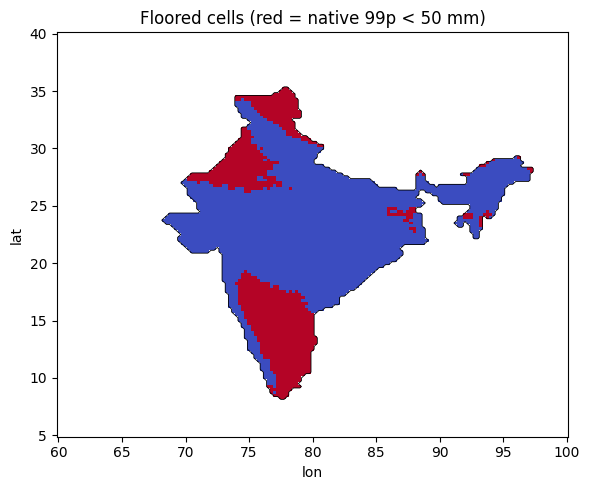

MAX — per-step centroid displacement by link type
link_type       n   med_km  med_deg  med_m/s   p90_km   p99_km
overlap      2305     57.6     0.54     0.67    149.5    264.5
fallback     2187    130.3     1.24     1.51    195.2    214.8
merge         179    111.7     1.06     1.29    234.0    382.0
split         132    110.9     1.02     1.28    231.1    348.8

Verified-same-object (overlap) envelope: p95=190.4 km, p99=264.5 km
  fallback steps  >  overlap-p95 :   270  (12.3% of fallbacks)  <- suspect separate systems
  fallback steps  >  overlap-p99 :     0  (0.0% of fallbacks)  <- very likely separate
Literature anchor: monsoon LPS move ~2 m/s (~1.5-1.7 deg/day);
a real ERE object (~1 deg wide) that moves >1 deg cannot self-overlap.
MIN — per-step centroid displacement by link type
link_type       n   med_km  med_deg  med_m/s   p90_km   p99_km
overlap      1960     52.6     0.50     0.61    138.4    250.4
fallback     2790    122.8     1.16     1.42    192.2    214.4
merge         

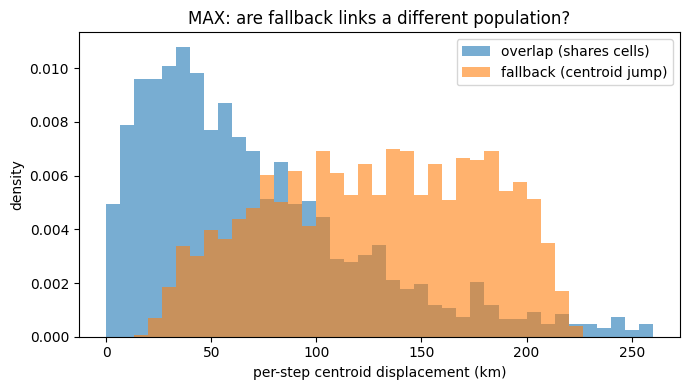

In [19]:
try:
    import matplotlib.pyplot as plt
    floored_grid = np.zeros_like(india_mask, dtype=float); floored_grid[:] = np.nan
    floored_grid[valid_cell] = 0.0
    floored_grid[in_india & ~np.isnan(native_all) & (native_all < FLOOR_MM)] = 1.0
    fig, ax = plt.subplots(figsize=(6, 5))
    LON, LAT = np.meshgrid(lon, lat)
    ax.pcolormesh(LON, LAT, floored_grid, shading='auto', cmap='coolwarm', vmin=0, vmax=1)
    ax.contour(LON, LAT, india_mask.astype(int), levels=[0.5], colors='k', linewidths=0.6)
    ax.set_title("Floored cells (red = native 99p < 50 mm)")
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("map skipped:", e)
 
 
# ── Cell B : ARE CONTINUATIONS MEANINGFUL?  (points 2, 3, 6) ─────────
# Empirical per-step centroid displacement, split by link_type.
# Overlap steps share cells -> they tell us how far a VERIFIED same-object
# moves per day. Fallback steps far beyond that are likely separate systems.
import numpy as np
import pandas as pd
 
def hav_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    p1, p2 = np.radians(lat1), np.radians(lat2)
    dphi   = np.radians(lat2 - lat1)
    dlmb   = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(p1)*np.cos(p2)*np.sin(dlmb/2)**2
    return 2*R*np.arcsin(np.sqrt(a))
 
def step_displacements(df_stats):
    """Distance from each object-day to the previous object-day in its track."""
    d = df_stats.sort_values(['track_num', 'day_of_track']).copy()
    g = d.groupby('track_num')
    plat = g['centroid_lat'].shift(1).values
    plon = g['centroid_lon'].shift(1).values
    d['step_km']  = hav_km(plat, plon, d['centroid_lat'].values, d['centroid_lon'].values)
    d['step_deg'] = np.sqrt((d['centroid_lat'].values - plat)**2 +
                            (d['centroid_lon'].values - plon)**2)
    d['step_ms']  = d['step_km'] * 1000.0 / 86400.0          # km/day -> m/s
    return d[d['day_of_track'] > 0]                          # drop birth rows
 
def meaningfulness_report(tag, df_stats):
    steps = step_displacements(df_stats)
    print("="*72)
    print(f"{tag} — per-step centroid displacement by link type")
    print("="*72)
    print(f"{'link_type':<10}{'n':>7}{'med_km':>9}{'med_deg':>9}"
          f"{'med_m/s':>9}{'p90_km':>9}{'p99_km':>9}")
    for lt in ['overlap', 'fallback', 'merge', 'split']:
        g = steps[steps['link_type'] == lt]['step_km']
        gd = steps[steps['link_type'] == lt]['step_deg']
        gm = steps[steps['link_type'] == lt]['step_ms']
        if len(g) == 0:
            continue
        print(f"{lt:<10}{len(g):>7}{g.median():>9.1f}{gd.median():>9.2f}"
              f"{gm.median():>9.2f}{g.quantile(.9):>9.1f}{g.quantile(.99):>9.1f}")
 
    # --- the key test: fallback steps beyond the overlap-step envelope ---
    ov = steps[steps['link_type'] == 'overlap']['step_km']
    fb = steps[steps['link_type'] == 'fallback']['step_km']
    if len(ov) and len(fb):
        p95, p99 = ov.quantile(.95), ov.quantile(.99)
        print(f"\nVerified-same-object (overlap) envelope: p95={p95:.1f} km, p99={p99:.1f} km")
        print(f"  fallback steps  >  overlap-p95 : {int((fb > p95).sum()):5d}"
              f"  ({(fb > p95).mean()*100:.1f}% of fallbacks)  <- suspect separate systems")
        print(f"  fallback steps  >  overlap-p99 : {int((fb > p99).sum()):5d}"
              f"  ({(fb > p99).mean()*100:.1f}% of fallbacks)  <- very likely separate")
    print("Literature anchor: monsoon LPS move ~2 m/s (~1.5-1.7 deg/day);")
    print("a real ERE object (~1 deg wide) that moves >1 deg cannot self-overlap.")
 
meaningfulness_report('MAX', stats_max)
meaningfulness_report('MIN', stats_min)
 
# optional: displacement histograms (overlap vs fallback), MAX
try:
    import matplotlib.pyplot as plt
    s = step_displacements(stats_max)
    fig, ax = plt.subplots(figsize=(7, 4))
    bins = np.linspace(0, s['step_km'].quantile(.99), 40)
    ax.hist(s[s.link_type == 'overlap']['step_km'],  bins=bins, alpha=.6,
            label='overlap (shares cells)', density=True)
    ax.hist(s[s.link_type == 'fallback']['step_km'], bins=bins, alpha=.6,
            label='fallback (centroid jump)', density=True)
    ax.set_xlabel("per-step centroid displacement (km)")
    ax.set_ylabel("density"); ax.set_title("MAX: are fallback links a different population?")
    ax.legend(); plt.tight_layout(); plt.show()
except Exception as e:
    print("hist skipped:", e)
 